ESCENARIO 01 GEMINI - CON REGLAS, VERSIÓN PAGA

REPORTE DE AVANCE FÍSICO Y CONTROL DE OBRA
Avance Físico Consolidado General: 61.14%

Avance por Disciplina:
 - Civil: 87.39%
 - Eléctrica: 51.46%
 - Instrumentación: 31.42%
 - Mecánica estática: 69.27%
 - Rotativa: 26.21%

----------------------------------------
INDICADORES DE VALOR GANADO (EVM)
----------------------------------------
Valor Planificado (PV) : USD 39,520,591.76
Valor Ganado (EV)      : USD 33,947,130.85
Costo Real (AC)        : USD 35,031,285.00
SPI (Eficiencia Plazo) : 0.859
CPI (Eficiencia Costo) : 0.969

Interpretación:
 - SPI: Atraso en Cronograma
 - CPI: Sobrecosto

----------------------------------------
INCONSISTENCIAS DETECTADAS EN DATASET
----------------------------------------
❌ ID STAP-CIV-005: Cantidad ejecutada (67) es mayor a la planificada (63).
❌ ID STAP-CIV-030: Unidad 'm^3' no reconocida.
❌ ID STAP-MEC-012: Cantidad ejecutada (814) es mayor a la planificada (775).
❌ ID STAP-INS-009: Unidad 'ml' no reconocida.
❌ ID STAP-ELE-007: Cantidad ejecutada 

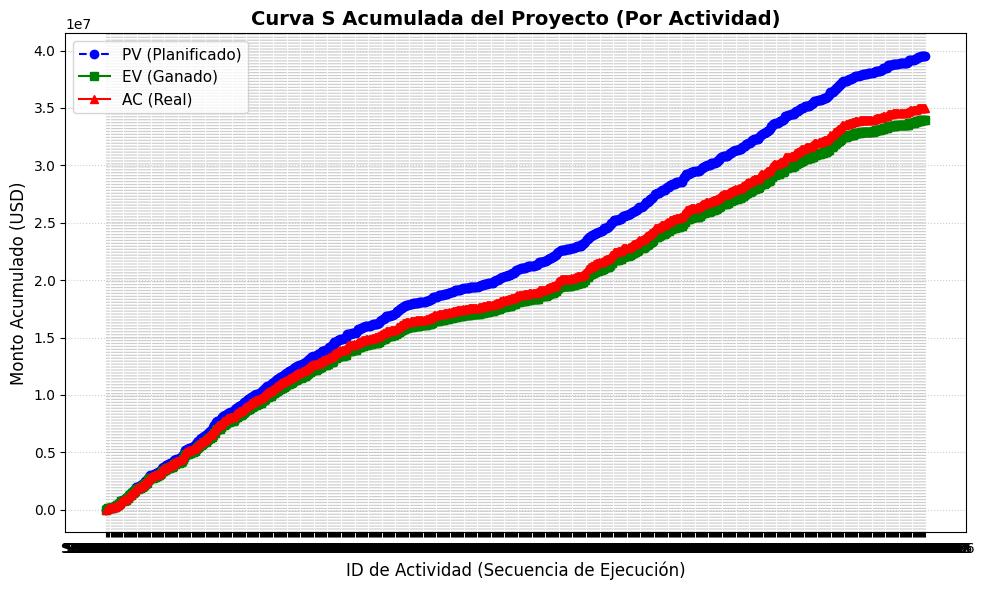

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# CONFIGURACIÓN Y GENERACIÓN DE DATOS DE PRUEBA (Para Google Colab)
# =====================================================================
FILENAME = "02_Dataset_Base_STAP.csv"

def generar_datos_prueba():
    """Genera un archivo CSV de prueba con datos válidos e inconsistencias"""
    data = [
        # id, disciplina, desc, unidad, cant_plan, cant_ejec, peso_usd, av_plan_pct, costo_real
        (1, "Civil", "Excavación", "m3", 100, 40, 5000, 0.50, 2200),
        (2, "Civil", "Concreto", "m3", 50, 55, 8000, 0.30, 9000), # Alerta: cant_ejec > cant_plan
        (3, "Mecánica estática", "Montaje Tanque", "und", 2, 1, 15000, 0.40, 6000),
        (4, "Rotativa", "Alineación Bomba", "und", 4, 4, 4000, 1.00, 3800),
        (5, "Instrumentación", "Calibración", "pulg_diam", 10, 2, 2000, 0.10, 500), # Alerta: unidad rara para inst. pero válida
        (5, "Eléctrica", "Tendido Cables", "m", 200, 100, 3000, 0.60, 1200), # Alerta: ID duplicado (5)
        (6, "Falsa Disciplina", "Tubería", "m", 80, 40, 6000, 0.50, 2500), # Alerta: Disciplina no válida
        (7, "Eléctrica", "Tableros", "error_und", 5, 2, 4000, 0.20, 1800), # Alerta: Unidad no válida
        (8, "Civil", "Acabados", "m2", 120, 0, -500, 0.10, 0), # Alerta: Peso negativo
        (9, "Instrumentación", "Lazos", "und", 30, 15, 3000, 1.50, 1400) # Alerta: av_plan_pct > 1
    ]

    columns = [
        "id_actividad", "disciplina", "descripcion", "unidad",
        "cantidad_planificada", "cantidad_ejecutada",
        "peso_presupuesto_usd", "avance_planificado_pct", "costo_real_usd"
    ]

    df_prueba = pd.DataFrame(data, columns=columns)
    df_prueba.to_csv(FILENAME, index=False, encoding="utf-8")
    print(GEN_MSG)

GEN_MSG = f" [INFO] Archivo de prueba '{FILENAME}' generado automáticamente para la simulación.\n"

# Asegurar que exista el archivo en el entorno de Colab
if not os.path.exists(FILENAME):
    generar_datos_prueba()


# =====================================================================
# PROGRAMA PRINCIPAL DE CONTROL DE PROYECTOS
# =====================================================================
def ejecutar_control_obra():
    # 1. Cargar Dataset
    try:
        df = pd.read_csv(FILENAME, encoding="utf-8")
    except Exception as e:
        print(f"Error al abrir el archivo: {e}")
        return

    inconsistencias = []

    # Listas de valores válidos para validación
    unidades_validas = {"pulg_diam", "kg", "m", "m2", "m3", "und"}
    disciplinas_validas = {"Civil", "Mecánica estática", "Rotativa", "Instrumentación", "Eléctrica"}
    ids_vistos = set()

    # 2. Validaciones fila por fila (sin detener el programa)
    for idx, row in df.iterrows():
        act_id = row['id_actividad']

        # ID duplicado
        if act_id in ids_vistos:
            inconsistencias.append(f"ID {act_id}: ID de actividad duplicado.")
        ids_vistos.add(act_id)

        # Cantidad ejecutada mayor a la planificada
        if row['cantidad_ejecutada'] > row['cantidad_planificada']:
            inconsistencias.append(f"ID {act_id}: Cantidad ejecutada ({row['cantidad_ejecutada']}) es mayor a la planificada ({row['cantidad_planificada']}).")

        # Peso presupuestal nulo, negativo o ausente
        if pd.isna(row['peso_presupuesto_usd']) or row['peso_presupuesto_usd'] <= 0:
            inconsistencias.append(f"ID {act_id}: Peso presupuestal inválido, nulo o negativo ({row['peso_presupuesto_usd']}).")

        # Unidad no reconocida
        if row['unidad'] not in unidades_validas:
            inconsistencias.append(f"ID {act_id}: Unidad '{row['unidad']}' no reconocida.")

        # Disciplina no reconocida
        if row['disciplina'] not in disciplinas_validas:
            inconsistencias.append(f"ID {act_id}: Disciplina '{row['disciplina']}' no reconocida.")

        # Avance planificado fuera de rango [0, 1]
        if row['avance_planificado_pct'] < 0 or row['avance_planificado_pct'] > 1:
            inconsistencias.append(f"ID {act_id}: Avance planificado ({row['avance_planificado_pct']}) fuera del rango [0, 1].")

    # 3. Reglas de Cálculo de Avance
    # Regla 1: Avance de cada actividad acotado a [0,1]
    # Evitamos división por cero si cantidad_planificada es 0
    df['avance_actividad'] = df.apply(
        lambda r: min(max(r['cantidad_ejecutada'] / r['cantidad_planificada'], 0.0), 1.0)
        if r['cantidad_planificada'] > 0 else 0.0, axis=1
    )

    # Para los cálculos globales y por disciplina, filtramos pesos inválidos para no distorsionar el peso financiero.
    df_calculo = df[df['peso_presupuesto_usd'] > 0].copy()

    sum_peso_total = df_calculo['peso_presupuesto_usd'].sum()

    # Regla 2: Avance físico consolidado
    if sum_peso_total > 0:
        avance_fisico_consolidado = (df_calculo['avance_actividad'] * df_calculo['peso_presupuesto_usd']).sum() / sum_peso_total
    else:
        avance_fisico_consolidado = 0.0

    # Regla 3: Avance por disciplina
    print("="*60)
    print("REPORTE DE AVANCE FÍSICO Y CONTROL DE OBRA")
    print("="*60)
    print(f"Avance Físico Consolidado General: {avance_fisico_consolidado * 100:.2f}%\n")

    print("Avance por Disciplina:")
    # Solo agrupamos disciplinas válidas y con peso correcto
    df_valid_disc = df_calculo[df_calculo['disciplina'].isin(disciplinas_validas)]
    grouped = df_valid_disc.groupby('disciplina')

    for disc, group in grouped:
        peso_disc = group['peso_presupuesto_usd'].sum()
        if peso_disc > 0:
            av_disc = (group['avance_actividad'] * group['peso_presupuesto_usd']).sum() / peso_disc
            print(f" - {disc}: {av_disc * 100:.2f}%")
        else:
            print(f" - {disc}: 0.00% (Sin peso presupuestal válido)")

    # 4. Valor Ganado (EVM)
    # PV = Σ(peso_i × avance_planificado_pct_i)
    pv_total = (df_calculo['peso_presupuesto_usd'] * df_calculo['avance_planificado_pct'].clip(0,1)).sum()
    # EV = Σ(peso_i × avance_i)
    ev_total = (df_calculo['peso_presupuesto_usd'] * df_calculo['avance_actividad']).sum()
    # AC = Σ(costo_real_usd_i)
    ac_total = df_calculo['costo_real_usd'].sum() if 'costo_real_usd' in df_calculo.columns else df_calculo['costo_real_usd_i'].sum()

    # Índices SPI y CPI evitando división por cero
    spi = ev_total / pv_total if pv_total > 0 else 1.0
    cpi = ev_total / ac_total if ac_total > 0 else 1.0

    print("\n" + "-"*40)
    print("INDICADORES DE VALOR GANADO (EVM)")
    print("-"*40)
    print(f"Valor Planificado (PV) : USD {pv_total:,.2f}")
    print(f"Valor Ganado (EV)      : USD {ev_total:,.2f}")
    # En el dataset dice costo_real_usd pero el requisito num 4 dice costo_real_usd_i, ambas se mapean al costo real.
    print(f"Costo Real (AC)        : USD {ac_total:,.2f}")
    print(f"SPI (Eficiencia Plazo) : {spi:.3f}")
    print(f"CPI (Eficiencia Costo) : {cpi:.3f}")

    # Interpretación textual
    interpreta_spi = "Adelanto en Cronograma" if spi >= 1.0 else "Atraso en Cronograma"
    interpreta_cpi = "Ahorro en Costo" if cpi >= 1.0 else "Sobrecosto"

    print(f"\nInterpretación:")
    print(f" - SPI: {interpreta_spi}")
    print(f" - CPI: {interpreta_cpi}")

    # 5. Lista de Inconsistencias Detectadas
    print("\n" + "-"*40)
    print("INCONSISTENCIAS DETECTADAS EN DATASET")
    print("-"*40)
    if inconsistencias:
        for inc in inconsistencias:
            print(f"❌ {inc}")
    else:
        print("✓ No se detectaron inconsistencias en el archivo.")
    print("="*60)

    # 6. Dibuja la curva S
    # Como el archivo es un listado de actividades y no un histórico por fechas,
    # simulamos la curva S acumulando los valores ordenados por el ID de actividad
    # para reflejar el comportamiento acumulativo del proyecto.
    df_calculo = df_calculo.sort_values(by='id_actividad').reset_index(drop=True)

    df_calculo['PV_acum'] = (df_calculo['peso_presupuesto_usd'] * df_calculo['avance_planificado_pct'].clip(0,1)).cumsum()
    df_calculo['EV_acum'] = (df_calculo['peso_presupuesto_usd'] * df_calculo['avance_actividad']).cumsum()
    df_calculo['AC_acum'] = df_calculo['costo_real_usd'].cumsum()

    plt.figure(figsize=(10, 6))
    plt.plot(df_calculo['id_actividad'].astype(str), df_calculo['PV_acum'], marker='o', label='PV (Planificado)', color='blue', linestyle='--')
    plt.plot(df_calculo['id_actividad'].astype(str), df_calculo['EV_acum'], marker='s', label='EV (Ganado)', color='green')
    plt.plot(df_calculo['id_actividad'].astype(str), df_calculo['AC_acum'], marker='^', label='AC (Real)', color='red')

    plt.title('Curva S Acumulada del Proyecto (Por Actividad)', fontsize=14, fontweight='bold')
    plt.xlabel('ID de Actividad (Secuencia de Ejecución)', fontsize=12)
    plt.ylabel('Monto Acumulado (USD)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Ejecución directa
ejecutar_control_obra()